In [104]:
# import torchmetrics
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import Compose, ToTensor

In [44]:
images = "/Users/aleksandraciesinska/Desktop/projekty/TennisVision/data/Tennis Player Actions Dataset for Human Pose Estimation/images"

In [45]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [ ]:
transform_train = Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

transform_val = Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

transform_test = transform_val

In [60]:
ds_train_all = datasets.ImageFolder(root=images, transform=transform_train)
ds_val_all = datasets.ImageFolder(root=images, transform=transform_val)
ds_test_all = datasets.ImageFolder(root=images, transform=transform_test)

In [61]:
ds_train_all.class_to_idx.items()

dict_items([('backhand', 0), ('forehand', 1), ('ready_position', 2), ('serve', 3)])

In [77]:
targets = np.array(ds_train_all.targets)

In [80]:
targets

array([0, 0, 0, ..., 3, 3, 3], shape=(2000,))

In [81]:
idx = np.arange(len(targets))

In [ ]:
idx_train, idx_test = train_test_split(idx, test_size=0.1,
                                       random_state=42,
                                       stratify=targets)
# stratifying the split so each class has a similar share

In [85]:
targets_train = targets[idx_train]

idx_train, idx_val = train_test_split(idx_train, test_size=0.111111, # 0.111111 from 90% gives 10% from the whole set
                                      random_state=42, stratify=targets_train)  


In [86]:
train_ds = Subset(ds_train_all, idx_train)
val_ds = Subset(ds_val_all, idx_val)
test_ds = Subset(ds_test_all, idx_test)

In [88]:
len(train_ds), len(val_ds), len(test_ds)

(1600, 200, 200)

In [154]:
torch.manual_seed(42)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
valid_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

In [63]:
batch_images, batch_labels = next(iter(train_loader))

In [64]:
def plot_image(image): # plt needs HWC
    plt.imshow(image.permute(1,2,0))
    plt.axis("off")

In [65]:
idx_to_class = {v: k for k, v in ds_train_all.class_to_idx.items()}

In [66]:
idx_to_class

{0: 'backhand', 1: 'forehand', 2: 'ready_position', 3: 'serve'}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.843908..2.3262744].


ready_position


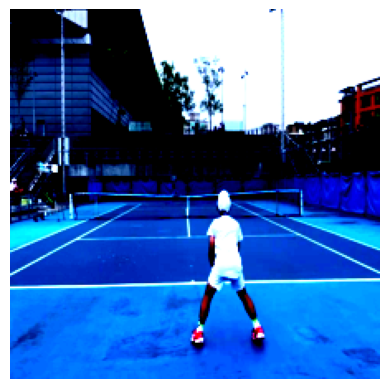

In [67]:
plot_image(batch_images[0])
print(idx_to_class[int(batch_labels[0])])

In [ ]:
def show_batch(images, labels, n=12, ncols=4, denormalize=False):
    images = images[:n]
    labels = labels[:n]

    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
    axes = axes.flatten()

    for i in range(n):
        img = images[i].permute(1,2,0) #  # CHW -> HWC

        if denormalize:
            mean = torch.tensor([0.485, 0.456, 0.406]).view(1,1,3) # make (1,1,3) from (3,)
            std  = torch.tensor([0.229, 0.224, 0.225]).view(1,1,3)
            img = (img * std + mean).clamp(0,1)

        axes[i].imshow(img)
        axes[i].set_title(idx_to_class[int(labels[i])])
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()

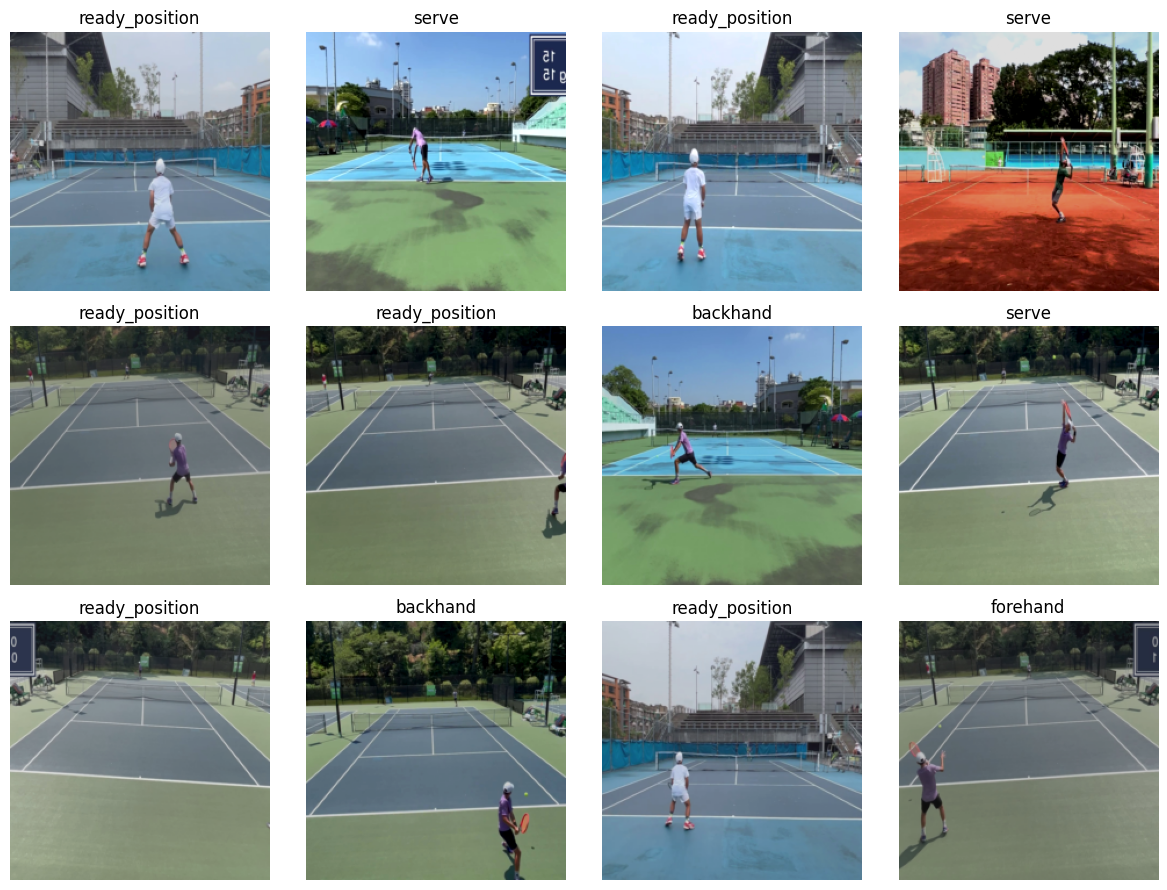

In [95]:
show_batch(batch_images, batch_labels, denormalize=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.843908..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0648367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..1.4373858].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8556864].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.2914162].

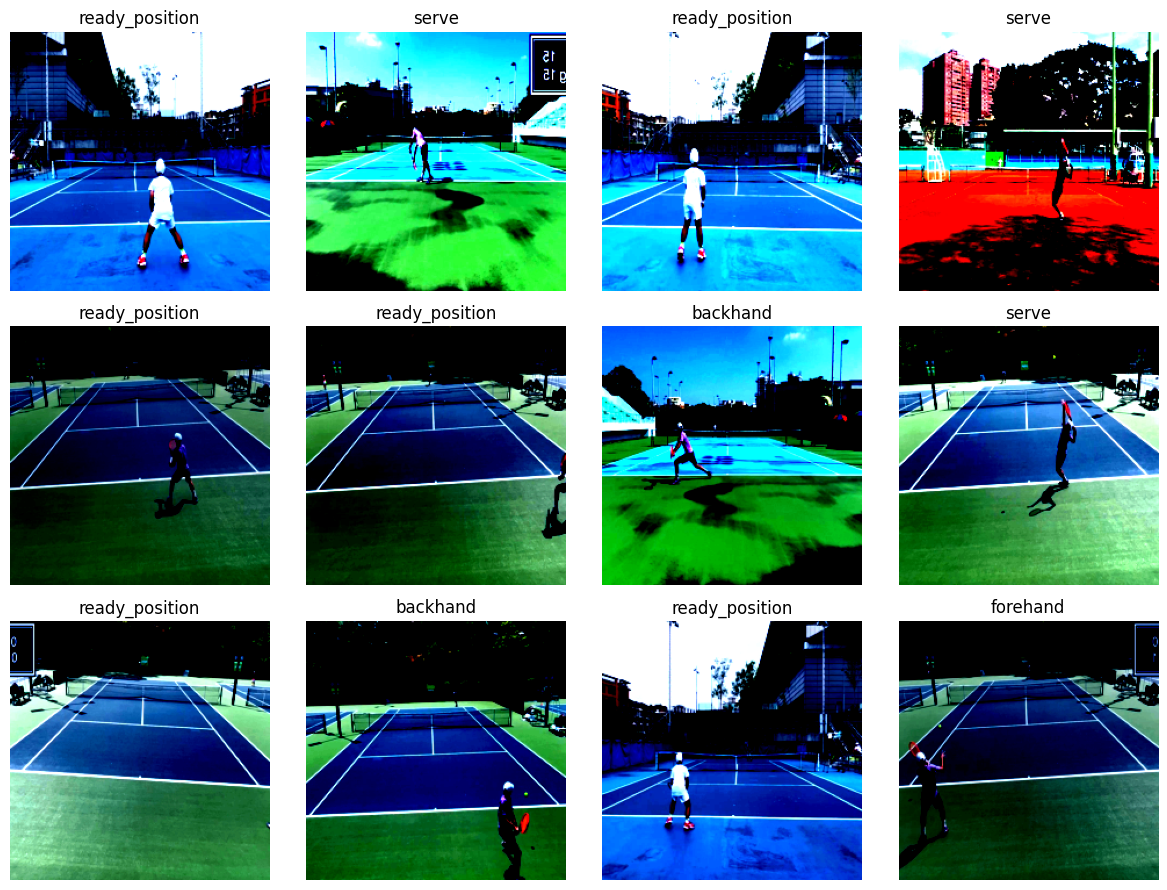

In [96]:
show_batch(batch_images, batch_labels, denormalize=False)

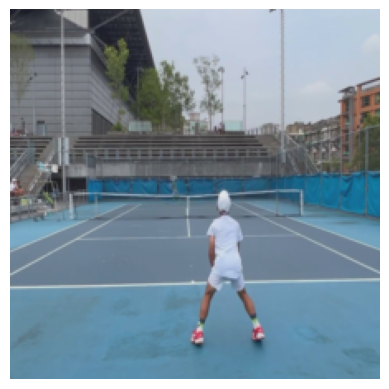

In [105]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

img = (batch_images[0] * std + mean).clamp(0,1)
plot_image(img)

## Training

In [160]:
def evaluate(model, data_loader, metric):
    model.eval()
    metric.reset()

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
        return metric.compute()

In [162]:
def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs):
    history = {"train_losses" : [],"train_metrics": [], "valid_metrics" : []}
    
    for epoch in range(n_epochs):
        total_loss = 0
        metric.reset()
        model.train()

        for X_batch , y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate(model, valid_loader, metric).item()
        )

        print(f"Epoch {epoch + 1}/{n_epochs}, "
            f"train loss: {history['train_losses'][-1]:.4f}, "
            f"train metric: {history['train_metrics'][-1]:.4f}, "
            f"valid metric: {history['valid_metrics'][-1]:.4f}")

    return history

In [138]:
num_classes = len(ds_train_all.classes)

In [139]:
from torchvision.models import ResNet18_Weights, ResNet50_Weights, resnet18

starting with a stable baseline:

In [140]:
def build_resnet18(num_classes, pretrained=True):
    weights = ResNet18_Weights.DEFAULT if pretrained else None
    model = resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model, weights 

In [ ]:
def build_resnet50(num_classes, pretrained=True):
    weights = ResNet50_Weights.DEFAULT if pretrained else None
    model = resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model, weights 

In [141]:
def freeze_backbone(model):
    for p in model.parameters():
        p.requires_grad = False

In [143]:
def unfreeze_head(model):
    for name, p in model.named_parameters():
        if any(k in name for k in ["fc", "classifier", "heads.head"]):
            p.requires_grad = True

In [180]:
def make_optimizer(model, lr=1e-3, wd = 1e-4):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=wd)

In [ ]:
model, weights = build_resnet18(num_classes=num_classes, pretrained=True)
freeze_backbone(model)
unfreeze_head(model)
model = model.to(device)
optimizer = make_optimizer(model, lr=1e-3)

In [156]:
# optimizer only for trainable parameters:

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(device)

In [ ]:
# unfreezing last block (e.g layer4 in ResNet)
for p in model.layer4.parameters():
    p.requires_grad=True

In [166]:
history = train(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    metric=metric,
    train_loader=train_loader,
    valid_loader=valid_loader,
    n_epochs=20,
)


Epoch 1/20, train loss: 0.6034, train metric: 0.7894, valid metric: 0.7100
Epoch 2/20, train loss: 0.5966, train metric: 0.7744, valid metric: 0.7600
Epoch 2/20, train loss: 0.5966, train metric: 0.7744, valid metric: 0.7600
Epoch 3/20, train loss: 0.5746, train metric: 0.7837, valid metric: 0.7000
Epoch 3/20, train loss: 0.5746, train metric: 0.7837, valid metric: 0.7000
Epoch 4/20, train loss: 0.5847, train metric: 0.7619, valid metric: 0.7550
Epoch 4/20, train loss: 0.5847, train metric: 0.7619, valid metric: 0.7550
Epoch 5/20, train loss: 0.5533, train metric: 0.7975, valid metric: 0.7050
Epoch 5/20, train loss: 0.5533, train metric: 0.7975, valid metric: 0.7050
Epoch 6/20, train loss: 0.5618, train metric: 0.7794, valid metric: 0.6900
Epoch 6/20, train loss: 0.5618, train metric: 0.7794, valid metric: 0.6900
Epoch 7/20, train loss: 0.5345, train metric: 0.8094, valid metric: 0.7550
Epoch 7/20, train loss: 0.5345, train metric: 0.8094, valid metric: 0.7550
Epoch 8/20, train loss: 0

In [165]:
model.fc

Linear(in_features=512, out_features=4, bias=True)

In [168]:
for param in model.parameters():
    p.requires_grad=True

In [169]:
history = train(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    metric=metric,
    train_loader=train_loader,
    valid_loader=valid_loader,
    n_epochs=5,
)

Epoch 1/5, train loss: 0.4475, train metric: 0.8438, valid metric: 0.7500
Epoch 2/5, train loss: 0.4309, train metric: 0.8400, valid metric: 0.7350
Epoch 2/5, train loss: 0.4309, train metric: 0.8400, valid metric: 0.7350
Epoch 3/5, train loss: 0.4270, train metric: 0.8388, valid metric: 0.7550
Epoch 3/5, train loss: 0.4270, train metric: 0.8388, valid metric: 0.7550
Epoch 4/5, train loss: 0.4434, train metric: 0.8275, valid metric: 0.6950
Epoch 4/5, train loss: 0.4434, train metric: 0.8275, valid metric: 0.6950
Epoch 5/5, train loss: 0.4092, train metric: 0.8562, valid metric: 0.7500
Epoch 5/5, train loss: 0.4092, train metric: 0.8562, valid metric: 0.7500


## ResNet18

In [191]:
model, weights = build_resnet18(num_classes=num_classes, pretrained=True)
freeze_backbone(model)
unfreeze_head(model)
model = model.to(device)
optimizer = make_optimizer(model, lr=1e-3)

In [192]:
transform_val = weights.transforms()

ds_train = datasets.ImageFolder(root=images, transform=transform_train)
ds_val   = datasets.ImageFolder(root=images, transform=transform_val)
ds_test  = datasets.ImageFolder(root=images, transform=transform_val)

train_ds = Subset(ds_train, idx_train)
val_ds   = Subset(ds_val, idx_val)
test_ds  = Subset(ds_test, idx_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
valid_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)



In [193]:
history = train(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    metric=metric,
    train_loader=train_loader,
    valid_loader=valid_loader,
    n_epochs=5,
)

Epoch 1/5, train loss: 1.1845, train metric: 0.4756, valid metric: 0.5250
Epoch 2/5, train loss: 0.9272, train metric: 0.6388, valid metric: 0.5700
Epoch 2/5, train loss: 0.9272, train metric: 0.6388, valid metric: 0.5700
Epoch 3/5, train loss: 0.8359, train metric: 0.6906, valid metric: 0.5850
Epoch 3/5, train loss: 0.8359, train metric: 0.6906, valid metric: 0.5850
Epoch 4/5, train loss: 0.7572, train metric: 0.7169, valid metric: 0.5800
Epoch 4/5, train loss: 0.7572, train metric: 0.7169, valid metric: 0.5800
Epoch 5/5, train loss: 0.7116, train metric: 0.7487, valid metric: 0.6000
Epoch 5/5, train loss: 0.7116, train metric: 0.7487, valid metric: 0.6000


In [197]:
for p in model.layer4.parameters():
    p.requires_grad = True

optimzier = make_optimizer(model, lr=1e-4)
history_ft = train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs=8)

Epoch 1/8, train loss: 0.6940, train metric: 0.7462, valid metric: 0.6250
Epoch 2/8, train loss: 0.6570, train metric: 0.7581, valid metric: 0.5950
Epoch 2/8, train loss: 0.6570, train metric: 0.7581, valid metric: 0.5950
Epoch 3/8, train loss: 0.6405, train metric: 0.7638, valid metric: 0.5750
Epoch 3/8, train loss: 0.6405, train metric: 0.7638, valid metric: 0.5750
Epoch 4/8, train loss: 0.6325, train metric: 0.7688, valid metric: 0.6150
Epoch 4/8, train loss: 0.6325, train metric: 0.7688, valid metric: 0.6150
Epoch 5/8, train loss: 0.6106, train metric: 0.7744, valid metric: 0.6250
Epoch 5/8, train loss: 0.6106, train metric: 0.7744, valid metric: 0.6250
Epoch 6/8, train loss: 0.5752, train metric: 0.7825, valid metric: 0.6400
Epoch 6/8, train loss: 0.5752, train metric: 0.7825, valid metric: 0.6400
Epoch 7/8, train loss: 0.5688, train metric: 0.7900, valid metric: 0.6050
Epoch 7/8, train loss: 0.5688, train metric: 0.7900, valid metric: 0.6050
Epoch 8/8, train loss: 0.5768, train m

In [195]:
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in valid_loader:
        x = x.to(device)
        logits = model(x)
        pred = logits.argmax(1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(pred)

cm = confusion_matrix(y_true, y_pred)
print(cm)
print(classification_report(y_true, y_pred, target_names=ds_train.classes))



[[24  4 16  6]
 [16 18 11  5]
 [ 2  0 47  1]
 [ 3  6 10 31]]
                precision    recall  f1-score   support

      backhand       0.53      0.48      0.51        50
      forehand       0.64      0.36      0.46        50
ready_position       0.56      0.94      0.70        50
         serve       0.72      0.62      0.67        50

      accuracy                           0.60       200
     macro avg       0.61      0.60      0.58       200
  weighted avg       0.61      0.60      0.58       200



In [172]:
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

In [173]:
def build_efficientnet_b0(num_classes, pretrained=True):
    weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = efficientnet_b0(weights=weights)
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    return model, weights

In [ ]:
from torchvision.models import MobileNet_V3_Large_Weights, mobilenet_v3_large


def build_mobilenet_v3_large(num_classes, pretrained=True):
    weights = MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
    model = mobilenet_v3_large(weights=weights)
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    return model, weights


In [178]:
from torchvision.models import ConvNeXt_Tiny_Weights, convnext_tiny


def build_convnext_tiny(num_classes, pretrained=True):
    weights = ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
    model = convnext_tiny(weights=weights)
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    return model, weights
